#Data Preprocessing


In [12]:
# RetailBrain AI
# Notebook 02

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# libraries

In [13]:
# Install Libraries

!pip install -q ultralytics kaggle albumentations opencv-python

In [14]:
# Import Libraries

import os
import cv2
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [15]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mennahamdy090","key":"7a8c0f328b97b774acb0d249a0812cec"}'}

In [16]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle Ready")

Kaggle Ready


In [17]:
!kaggle datasets download \
-d thedatasith/sku110k-annotations \
-p /content

Dataset URL: https://www.kaggle.com/datasets/thedatasith/sku110k-annotations
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)
100% 13.2G/13.2G [02:02<00:00, 116MB/s]



In [18]:
!unzip -q /content/sku110k-annotations.zip -d /content/datasets

In [19]:
DATASET_ROOT = Path("/content/datasets/SKU110K_fixed")

print(DATASET_ROOT.exists())

True


In [20]:
train_images = list((DATASET_ROOT/"images/train").glob("*.jpg"))
val_images = list((DATASET_ROOT/"images/val").glob("*.jpg"))
test_images = list((DATASET_ROOT/"images/test").glob("*.jpg"))

print("Train :",len(train_images))
print("Validation :",len(val_images))
print("Test :",len(test_images))

Train : 8185
Validation : 584
Test : 2920


In [21]:
train_labels = list((DATASET_ROOT/"labels/train").glob("*.txt"))
val_labels = list((DATASET_ROOT/"labels/val").glob("*.txt"))
test_labels = list((DATASET_ROOT/"labels/test").glob("*.txt"))

print("Train Labels :",len(train_labels))
print("Validation Labels :",len(val_labels))
print("Test Labels :",len(test_labels))

Train Labels : 8185
Validation Labels : 584
Test Labels : 2920


In [24]:
#Check Missing Labels
missing = []

for img in tqdm(train_images):

    label = DATASET_ROOT/"labels/train"/(img.stem+".txt")

    if not label.exists():

        missing.append(img.name)

print("Missing Labels :",len(missing))

100%|██████████| 8185/8185 [00:00<00:00, 75209.22it/s]

Missing Labels : 0


In [23]:
#Check Corrupted Images
corrupted = []

for img in tqdm(train_images):

    image = cv2.imread(str(img))

    if image is None:

        corrupted.append(img.name)

print("Corrupted Images :",len(corrupted))

100%|██████████| 8185/8185 [07:10<00:00, 19.03it/s]

Corrupted Images : 0


In [25]:
#Empty Labels
empty_labels = []

for file in tqdm(train_labels):

    if os.path.getsize(file)==0:

        empty_labels.append(file.name)

print("Empty Labels :",len(empty_labels))

100%|██████████| 8185/8185 [00:00<00:00, 288493.00it/s]

Empty Labels : 0


In [26]:
#Bounding Box Validation
invalid_boxes = 0

for file in tqdm(train_labels):

    with open(file) as f:

        for line in f:

            values = line.strip().split()

            if len(values)!=5:

                invalid_boxes +=1

                continue

            cls,x,y,w,h = map(float,values)

            if not(0<=x<=1 and
                   0<=y<=1 and
                   0<w<=1 and
                   0<h<=1):

                invalid_boxes +=1

print("Invalid Boxes :",invalid_boxes)

100%|██████████| 8185/8185 [00:05<00:00, 1456.23it/s]

Invalid Boxes : 0


In [27]:
#Dataset Summary

summary = pd.DataFrame({

    "Split":["Train","Validation","Test"],

    "Images":[len(train_images),
              len(val_images),
              len(test_images)],

    "Labels":[len(train_labels),
              len(val_labels),
              len(test_labels)]

})

summary

,Split,Images,Labels
0,Train,8185,8185
1,Validation,584,584
2,Test,2920,2920


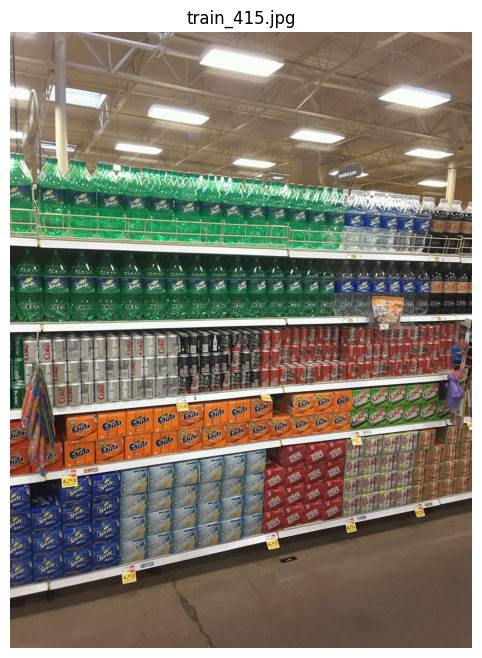

In [28]:
#Random Sample

sample = random.choice(train_images)

image = cv2.imread(str(sample))

image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(image)
plt.axis("off")
plt.title(sample.name)
plt.show()

In [29]:
#Image Size Statistics

sizes=[]

for img in tqdm(train_images):

    image=cv2.imread(str(img))

    h,w=image.shape[:2]

    sizes.append([w,h])

sizes=pd.DataFrame(sizes,columns=["Width","Height"])

sizes.describe()

100%|██████████| 8185/8185 [06:57<00:00, 19.61it/s]


,Width,Height
count,8185.000000,8185.000000
mean,2435.763714,3211.823335
std,425.094658,673.327764
min,480.000000,640.000000
25%,2336.000000,2560.000000
50%,2448.000000,3264.000000
75%,2448.000000,3264.000000
max,4320.000000,5312.000000


In [30]:
#Products per Image

products=[]

for file in tqdm(train_labels):

    with open(file) as f:

        products.append(len(f.readlines()))

products=pd.DataFrame(products,columns=["Products"])

products.describe()

100%|██████████| 8185/8185 [00:02<00:00, 3115.58it/s]


,Products
count,8185.000000
mean,147.008919
std,42.739776
min,1.000000
25%,123.000000
50%,138.000000
75%,161.000000
max,576.000000
